In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/zomato.csv")

# First 5 rows
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [5]:
# Shape of dataset
print("Rows and Columns:", df.shape)

# Column names
print("\nColumns:\n")
print(df.columns)

# Dataset information
print("\nDataset Info:\n")
print(df.info())

# Missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

Rows and Columns: (51717, 17)

Columns:

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509

In [6]:
# Checking missing values
missing_values = df.isnull().sum()

print(missing_values)

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64


In [7]:
# Dropping unnecessary columns

df = df.drop(['url', 'phone', 'dish_liked'], axis=1)

# Checking updated columns
print(df.columns)

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'location', 'rest_type', 'cuisines', 'approx_cost(for two people)',
       'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)'],
      dtype='object')


In [8]:
# Removing missing values

df.dropna(inplace=True)

# Checking remaining missing values
print(df.isnull().sum())

address                        0
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
reviews_list                   0
menu_item                      0
listed_in(type)                0
listed_in(city)                0
dtype: int64


In [9]:
# Checking duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 34


In [10]:
# Removing duplicate rows

df.drop_duplicates(inplace=True)

# Checking dataset shape after removing duplicates
print("New Shape:", df.shape)

New Shape: (43499, 14)


In [11]:
# Checking unique values in rate column

print(df['rate'].unique())

['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5' '3.2/5' '3.3/5' '2.8/5' '4.4/5' '4.3/5' 'NEW' '2.9/5' '3.5/5'
 '2.6/5' '3.8 /5' '3.4/5' '4.5/5' '2.5/5' '2.7/5' '4.7/5' '2.4/5' '2.2/5'
 '2.3/5' '3.4 /5' '-' '3.6 /5' '4.8/5' '3.9 /5' '4.2 /5' '4.0 /5' '4.1 /5'
 '3.7 /5' '3.1 /5' '2.9 /5' '3.3 /5' '2.8 /5' '3.5 /5' '2.7 /5' '2.5 /5'
 '3.2 /5' '2.6 /5' '4.5 /5' '4.3 /5' '4.4 /5' '4.9/5' '2.1/5' '2.0/5'
 '1.8/5' '4.6 /5' '4.9 /5' '3.0 /5' '4.8 /5' '2.3 /5' '4.7 /5' '2.4 /5'
 '2.1 /5' '2.2 /5' '2.0 /5' '1.8 /5']


In [2]:
# Removing 'NEW' values

df = df[df['rate'] != 'NEW']

# Removing '/5' from ratings
df['rate'] = df['rate'].str.replace('/5', '')

# Removing extra spaces
df['rate'] = df['rate'].str.strip()

# Convert datatype to float
df['rate'] = df['rate'].astype(float)

# Check datatype
print(df['rate'].dtype)

ValueError: could not convert string to float: '-'

In [13]:
# Remove rows with invalid ratings

df = df[df['rate'] != '-']

# Remove '/5'
df['rate'] = df['rate'].str.replace('/5', '')

# Remove spaces
df['rate'] = df['rate'].str.strip()

# Convert to float
df['rate'] = df['rate'].astype(float)

# Check datatype
print(df['rate'].dtype)

# Preview cleaned ratings
print(df['rate'].head())

float64
0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64


In [14]:
# Top restaurant locations

top_locations = df['location'].value_counts().head(10)

print(top_locations)

BTM                      3873
Koramangala 5th Block    2296
HSR                      1993
Indiranagar              1800
JP Nagar                 1710
Jayanagar                1634
Whitefield               1568
Marathahalli             1410
Bannerghatta Road        1226
Koramangala 7th Block    1055
Name: location, dtype: int64


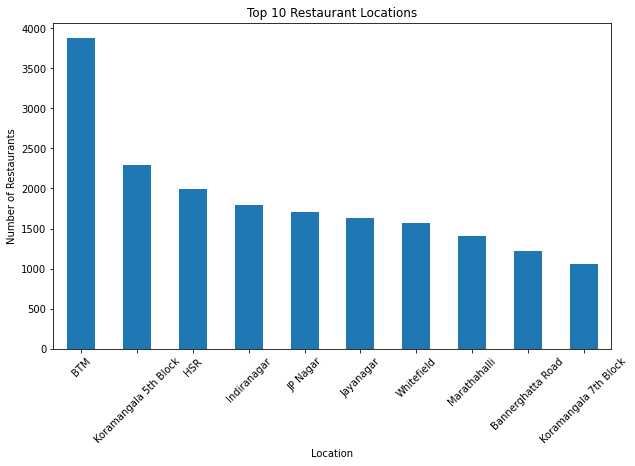

In [15]:
# Bar chart for top restaurant locations

top_locations.plot(kind='bar', figsize=(10,6))

plt.title("Top 10 Restaurant Locations")
plt.xlabel("Location")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

In [16]:
# Online order analysis

online_orders = df['online_order'].value_counts()

print(online_orders)

Yes    27081
No     14156
Name: online_order, dtype: int64


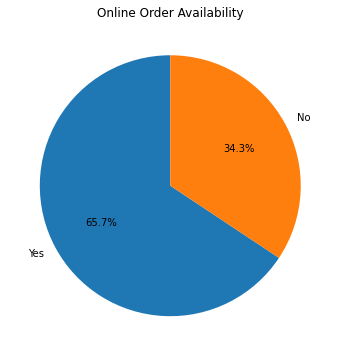

In [17]:
# Pie chart for online orders

plt.figure(figsize=(6,6))

online_orders.plot.pie(
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Online Order Availability")

plt.ylabel('')

plt.show()

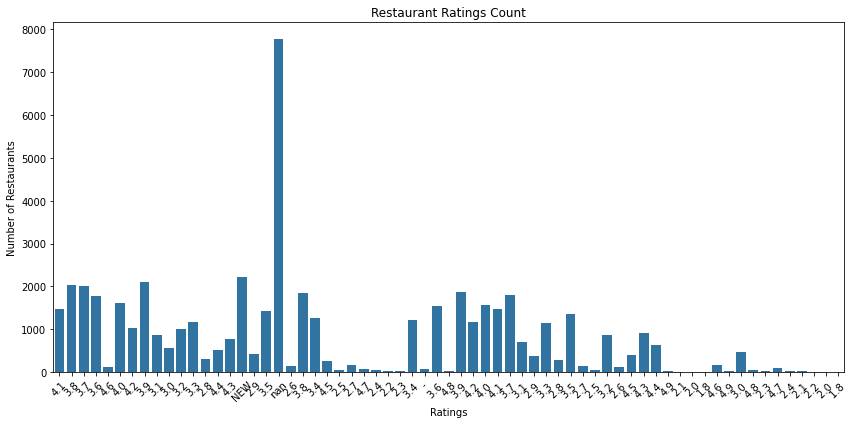

In [8]:
plt.figure(figsize=(12,6))

sns.countplot(
    x=df['rate'].astype(str).str.replace('/5', '', regex=False)
)

plt.title("Restaurant Ratings Count")

plt.xlabel("Ratings")

plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [9]:
# Remove rows where rating is NEW

df = df[df['rate'] != 'NEW']

# Remove rows where rating is -

df = df[df['rate'] != '-']

In [10]:
print(df['rate'].unique())

['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5' '3.2/5' '3.3/5' '2.8/5' '4.4/5' '4.3/5' '2.9/5' '3.5/5' nan
 '2.6/5' '3.8 /5' '3.4/5' '4.5/5' '2.5/5' '2.7/5' '4.7/5' '2.4/5' '2.2/5'
 '2.3/5' '3.4 /5' '3.6 /5' '4.8/5' '3.9 /5' '4.2 /5' '4.0 /5' '4.1 /5'
 '3.7 /5' '3.1 /5' '2.9 /5' '3.3 /5' '2.8 /5' '3.5 /5' '2.7 /5' '2.5 /5'
 '3.2 /5' '2.6 /5' '4.5 /5' '4.3 /5' '4.4 /5' '4.9/5' '2.1/5' '2.0/5'
 '1.8/5' '4.6 /5' '4.9 /5' '3.0 /5' '4.8 /5' '2.3 /5' '4.7 /5' '2.4 /5'
 '2.1 /5' '2.2 /5' '2.0 /5' '1.8 /5']


In [11]:
# Remove missing values

df = df.dropna(subset=['rate'])

In [12]:
print(df['rate'].unique())

['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5' '3.2/5' '3.3/5' '2.8/5' '4.4/5' '4.3/5' '2.9/5' '3.5/5' '2.6/5'
 '3.8 /5' '3.4/5' '4.5/5' '2.5/5' '2.7/5' '4.7/5' '2.4/5' '2.2/5' '2.3/5'
 '3.4 /5' '3.6 /5' '4.8/5' '3.9 /5' '4.2 /5' '4.0 /5' '4.1 /5' '3.7 /5'
 '3.1 /5' '2.9 /5' '3.3 /5' '2.8 /5' '3.5 /5' '2.7 /5' '2.5 /5' '3.2 /5'
 '2.6 /5' '4.5 /5' '4.3 /5' '4.4 /5' '4.9/5' '2.1/5' '2.0/5' '1.8/5'
 '4.6 /5' '4.9 /5' '3.0 /5' '4.8 /5' '2.3 /5' '4.7 /5' '2.4 /5' '2.1 /5'
 '2.2 /5' '2.0 /5' '1.8 /5']


In [13]:
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

In [14]:
print(df['rate'].head())

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: object


In [15]:
df['rate'] = df['rate'].astype(float)

In [16]:
print(df['rate'].dtype)

float64


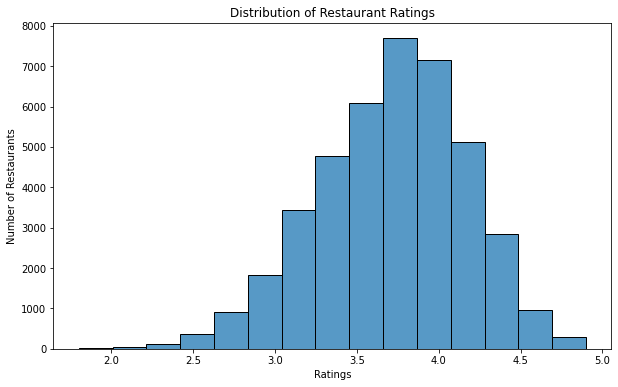

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(df['rate'], bins=15)

plt.title("Distribution of Restaurant Ratings")

plt.xlabel("Ratings")

plt.ylabel("Number of Restaurants")

plt.show()

In [18]:
df.groupby('online_order')['rate'].mean()

online_order
No     3.65907
Yes    3.72244
Name: rate, dtype: float64

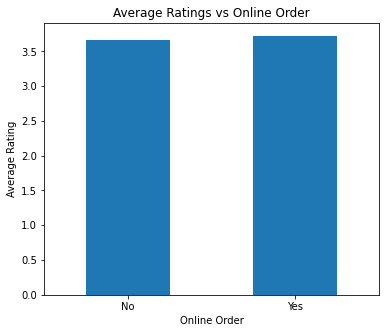

In [19]:
plt.figure(figsize=(6,5))

df.groupby('online_order')['rate'].mean().plot(kind='bar')

plt.title("Average Ratings vs Online Order")

plt.xlabel("Online Order")

plt.ylabel("Average Rating")

plt.xticks(rotation=0)

plt.show()

In [20]:
df['approx_cost(for two people)'].head()

0    800
1    800
2    800
3    300
4    600
Name: approx_cost(for two people), dtype: object

In [3]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)

ValueError: could not convert string to float: '1,200'

In [4]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)

In [5]:
print(df['approx_cost(for two people)'].dtype)

float64


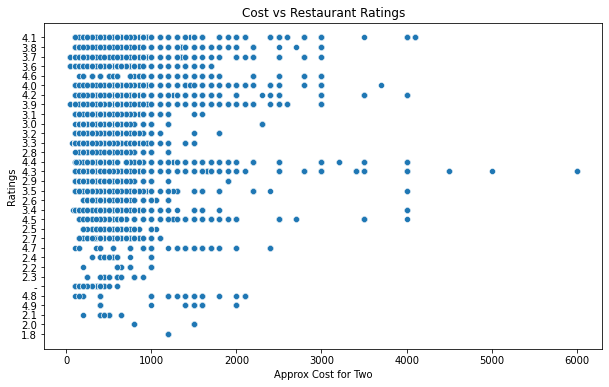

In [6]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['approx_cost(for two people)'],
    y=df['rate']
)

plt.title("Cost vs Restaurant Ratings")

plt.xlabel("Approx Cost for Two")

plt.ylabel("Ratings")

plt.show()

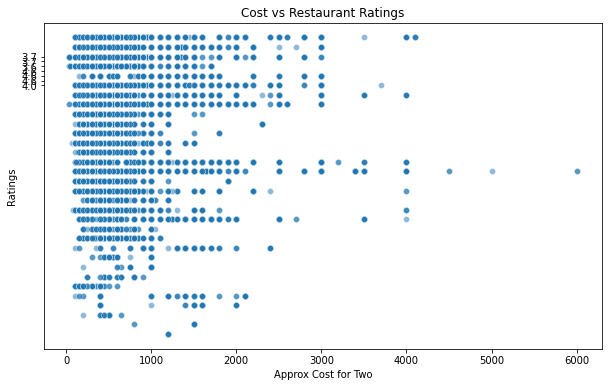

In [7]:

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['approx_cost(for two people)'],
    y=df['rate'],
    alpha=0.5
)

plt.title("Cost vs Restaurant Ratings")

plt.xlabel("Approx Cost for Two")

plt.ylabel("Ratings")

plt.yticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

plt.show()

In [8]:

df['rate'] = pd.to_numeric(df['rate'])


ValueError: Unable to parse string "-" at position 2893

In [9]:
df = df[df['rate'] != '-']

In [10]:
df['rate'] = pd.to_numeric(df['rate'])

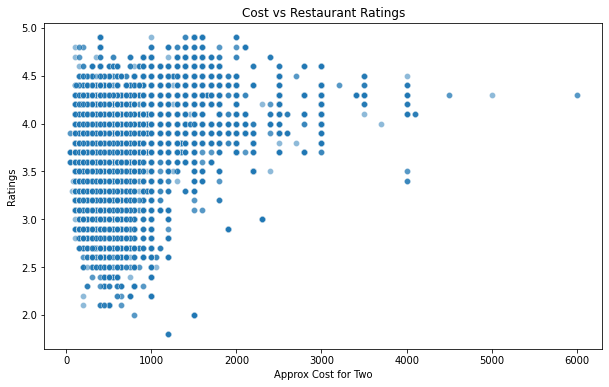

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['approx_cost(for two people)'],
    y=df['rate'],
    alpha=0.5
)

plt.title("Cost vs Restaurant Ratings")

plt.xlabel("Approx Cost for Two")

plt.ylabel("Ratings")

plt.yticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

plt.show()

In [12]:
# Selecting numeric columns

numeric_df = df[['rate', 'votes', 'approx_cost(for two people)']]

print(numeric_df.head())

   rate  votes  approx_cost(for two people)
0   4.1    775                        800.0
1   4.1    787                        800.0
2   3.8    918                        800.0
3   3.7     88                        300.0
4   3.8    166                        600.0


In [13]:
# Correlation matrix

correlation = numeric_df.corr()

print(correlation)

                                 rate     votes  approx_cost(for two people)
rate                         1.000000  0.434040                     0.385183
votes                        0.434040  1.000000                     0.382873
approx_cost(for two people)  0.385183  0.382873                     1.000000


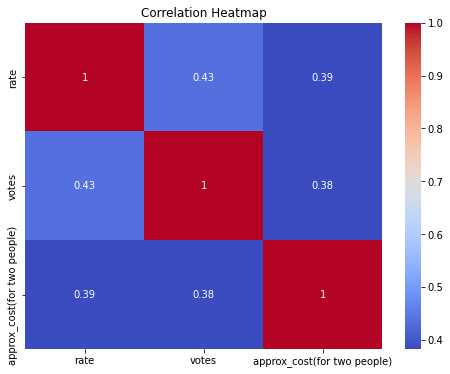

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [16]:
import pandas as pd

df = pd.read_csv("../data/zomato.csv")

df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [1]:
df.info()

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("../data/zomato.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [4]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [5]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

dish_liked                     54.291626
rate                           15.033741
phone                           2.335789
approx_cost(for two people)     0.669026
rest_type                       0.438927
cuisines                        0.087012
location                        0.040606
listed_in(type)                 0.000000
menu_item                       0.000000
reviews_list                    0.000000
url                             0.000000
address                         0.000000
votes                           0.000000
book_table                      0.000000
online_order                    0.000000
name                            0.000000
listed_in(city)                 0.000000
dtype: float64

In [6]:
df.drop('dish_liked', axis=1, inplace=True)

In [7]:
df.shape

(51717, 16)

In [8]:
df.duplicated().sum()

0

In [9]:
df['rate'].unique()[:10]

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5'], dtype=object)

In [10]:
df['rate'].value_counts().head(20)

NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
3.9 /5    1874
3.8 /5    1851
3.7 /5    1810
3.6/5     1773
4.0/5     1609
4.0 /5    1574
3.6 /5    1543
4.1 /5    1474
4.1/5     1474
3.5/5     1431
3.5 /5    1353
3.4/5     1259
3.4 /5    1217
3.3/5     1168
4.2 /5    1165
3.3 /5    1142
Name: rate, dtype: int64

In [11]:
# NEW aur '-' ko missing value bana do
df['rate'] = df['rate'].replace(['NEW', '-'], pd.NA)

# spaces remove karo
df['rate'] = df['rate'].str.replace(' ', '', regex=False)

# /5 remove karo
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

# numeric datatype me convert karo
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [12]:
df['rate'].head()

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

In [13]:
df['rate'].dtype

dtype('float64')

In [14]:
df['rate'].isnull().sum()

10052

In [15]:
df['rate'].fillna(df['rate'].median(), inplace=True)

In [16]:

df['rate'].isnull().sum()

0

In [17]:
df['approx_cost(for two people)'].head()

0    800
1    800
2    800
3    300
4    600
Name: approx_cost(for two people), dtype: object

In [18]:
df['approx_cost(for two people)'].dtype

dtype('O')

In [19]:
df['approx_cost(for two people)'].isnull().sum()

346

In [20]:
df['approx_cost(for two people)'].unique()[:20]

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000'], dtype=object)

In [21]:
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .str.replace(',', '', regex=False)
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

In [22]:
df['approx_cost(for two people)'].fillna(
    df['approx_cost(for two people)'].median(),
    inplace=True
)

In [23]:
df['approx_cost(for two people)'].dtype

dtype('float64')

In [24]:
df['approx_cost(for two people)'].isnull().sum()

0

In [25]:
df[['name','rate']].sort_values(
    by='rate',
    ascending=False
).head(10)

,name,rate
37843,Belgian Waffle Factory,4.9
34734,Asia Kitchen By Mainland China,4.9
10879,Asia Kitchen By Mainland China,4.9
39559,Punjab Grill,4.9
42381,Belgian Waffle Factory,4.9
29271,Asia Kitchen By Mainland China,4.9
32110,Asia Kitchen By Mainland China,4.9
49627,Byg Brewski Brewing Company,4.9
3921,Byg Brewski Brewing Company,4.9
4801,Byg Brewski Brewing Company,4.9


In [26]:
df['rate'].mean()

3.7003615832318193

In [27]:
df['approx_cost(for two people)'].mean()

554.3916893864687

In [28]:
df['online_order'].value_counts()

Yes    30444
No     21273
Name: online_order, dtype: int64

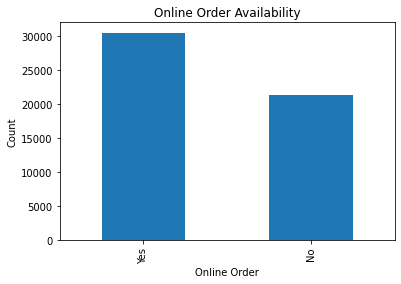

In [29]:
import matplotlib.pyplot as plt

df['online_order'].value_counts().plot(
    kind='bar'
)

plt.title("Online Order Availability")
plt.xlabel("Online Order")
plt.ylabel("Count")
plt.show()

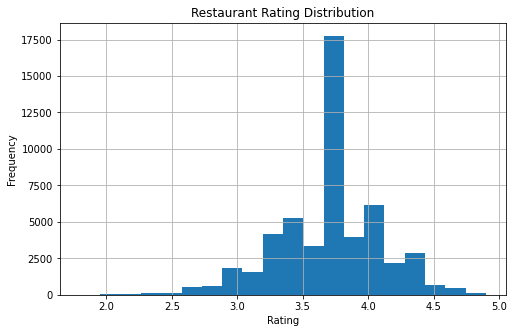

In [30]:
plt.figure(figsize=(8,5))

df['rate'].hist(
    bins=20
)

plt.title("Restaurant Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

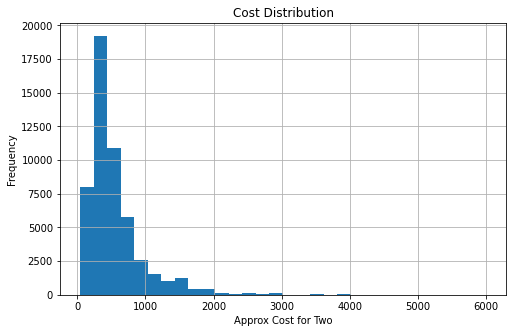

In [31]:
plt.figure(figsize=(8,5))

df['approx_cost(for two people)'].hist(
    bins=30
)

plt.title("Cost Distribution")
plt.xlabel("Approx Cost for Two")
plt.ylabel("Frequency")
plt.show()

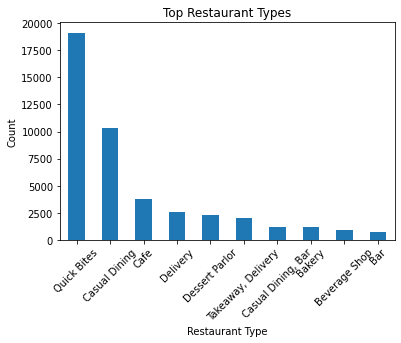

In [32]:
df['rest_type'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top Restaurant Types")
plt.xlabel("Restaurant Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

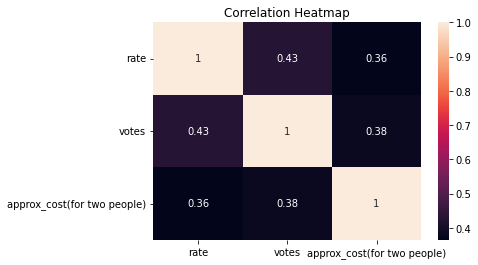

In [33]:
import seaborn as sns

numeric_df = df[
    ['rate',
     'votes',
     'approx_cost(for two people)']
]

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()